<a href="https://colab.research.google.com/github/mariakorotnian/Analysis-of-chocolate-sales/blob/main/Analysis_of_chocolate_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Uploading libraries, tables

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")


path = "/content/drive/MyDrive/ciocolata/calendar.csv"

calendar = pd.read_csv(path)
calendar.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [ ]:
path = "/content/drive/MyDrive/ciocolata/customers.csv"

customers = pd.read_csv(path)
customers.head()

,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


In [ ]:
path = "/content/drive/MyDrive/ciocolata/products.csv"

products = pd.read_csv(path)
products.head()

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


In [ ]:
path = "/content/drive/MyDrive/ciocolata/sales.csv"

sales = pd.read_csv(path)
sales.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [ ]:
path = "/content/drive/MyDrive/ciocolata/stores_corrected.csv"

stores = pd.read_csv(path)
stores.head()

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,USA,Retail
1,S002,Chocolate Store 2,Melbourne,Australia,Mall
2,S003,Chocolate Store 3,Berlin,Germany,Mall
3,S004,Chocolate Store 4,Paris,France,Airport
4,S005,Chocolate Store 5,Sydney,Australia,Online


##Checking for missing data


In [ ]:
print(calendar.isna().sum())

date           0
year           0
month          0
day            0
week           0
day_of_week    0
dtype: int64


In [ ]:
print(customers.isna().sum())

customer_id       0
age               0
gender            0
loyalty_member    0
join_date         0
dtype: int64


In [ ]:
print(products.isna().sum())

product_id       0
product_name     0
brand            0
category         0
cocoa_percent    0
weight_g         0
dtype: int64


In [ ]:
print(sales.isna().sum())

order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64


In [ ]:
print(stores.isna().sum())

store_id      0
store_name    0
city          0
country       0
store_type    0
dtype: int64


##Checking for duplicates

In [ ]:
duplicate_rows = calendar.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0      False
1      False
2      False
3      False
4      False
       ...  
726    False
727    False
728    False
729    False
730    False
Length: 731, dtype: bool
0


In [ ]:
duplicate_rows = customers.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool
0


In [ ]:
duplicate_rows = products.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool
0


In [ ]:
duplicate_rows = sales.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 1000000, dtype: bool
0


In [ ]:
duplicate_rows = stores.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool
0


##Checking data types and converting to the required type

In [ ]:
calendar.info()
customers.info()
products.info()
sales.info()
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         731 non-null    object
 1   year         731 non-null    int64 
 2   month        731 non-null    int64 
 3   day          731 non-null    int64 
 4   week         731 non-null    int64 
 5   day_of_week  731 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 34.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     50000 non-null  object
 1   age             50000 non-null  int64 
 2   gender          50000 non-null  object
 3   loyalty_member  50000 non-null  int64 
 4   join_date       50000 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2

In [ ]:
calendar["date"] = pd.to_datetime(calendar["date"])
calendar.info()

customers["join_date"] = pd.to_datetime(customers["join_date"])
customers.info()

sales["order_date"] = pd.to_datetime(sales["order_date"])
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         731 non-null    datetime64[ns]
 1   year         731 non-null    int64         
 2   month        731 non-null    int64         
 3   day          731 non-null    int64         
 4   week         731 non-null    int64         
 5   day_of_week  731 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 34.4 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     50000 non-null  object        
 1   age             50000 non-null  int64         
 2   gender          50000 non-null  object        
 3   loyalty_member  50000 non-null  int64         
 4   join_date       50000

##Examination for the presence of anomalies

In [ ]:
calendar.describe()

,date,year,month,day,week,day_of_week
count,731,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2024-01-01 00:00:00,2023.500684,6.519836,15.738714,26.465116,2.997264
min,2023-01-01 00:00:00,2023.000000,1.000000,1.000000,1.000000,0.000000
25%,2023-07-02 12:00:00,2023.000000,4.000000,8.000000,13.000000,1.000000
50%,2024-01-01 00:00:00,2024.000000,7.000000,16.000000,26.000000,3.000000
75%,2024-07-01 12:00:00,2024.000000,10.000000,23.000000,39.500000,5.000000
max,2024-12-31 00:00:00,2024.000000,12.000000,31.000000,52.000000,6.000000
std,NaN,0.500342,3.451913,8.809949,15.076602,2.004787


######*No* anomalies were *found*

In [ ]:
customers.describe()

,age,loyalty_member,join_date
count,50000.000000,50000.000000,50000
mean,44.026100,0.502080,2023-09-06 13:10:43.967999744
min,18.000000,0.000000,2021-03-06 00:00:00
25%,31.000000,0.000000,2022-06-03 00:00:00
50%,44.000000,1.000000,2023-09-07 00:00:00
75%,57.000000,1.000000,2024-12-09 00:00:00
max,70.000000,1.000000,2026-03-06 00:00:00
std,15.328333,0.500001,NaN


######*No* anomalies were *found*


In [ ]:
products.describe()

,cocoa_percent,weight_g
count,200.000000,200.000000
mean,69.150000,107.500000
std,14.623499,50.898954
min,50.000000,50.000000
25%,50.000000,80.000000
50%,70.000000,100.000000
75%,80.000000,120.000000
max,90.000000,200.000000


######*No* anomalies were *found*

In [ ]:
sales.describe()

,order_date,quantity,unit_price,discount,revenue,cost,profit
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023-12-31 19:03:34.991998720,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000
50%,2024-01-01 00:00:00,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000
std,NaN,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760


######*No* anomalies were *found*

In [ ]:
stores.describe()

,store_id,store_name,city,country,store_type
count,100,100,100,100,100
unique,100,100,7,6,4
top,S001,Chocolate Store 1,Toronto,Canada,Airport
freq,1,1,18,20,30


######*No* anomalies were *found*

##Joining tables using SQL

In [ ]:
!pip install pandasql
from pandasql import sqldf

query = """
SELECT s.order_id, s.order_date, s.product_id, s.store_id, s.customer_id, product_name, brand, category, cocoa_percent, weight_g, age, gender, loyalty_member, quantity, unit_price, discount, revenue, cost, store_name, city, country, store_type, year, month, day, week, day_of_week
FROM sales AS s
LEFT JOIN products AS p
    ON s.product_id = p.product_id
LEFT JOIN customers AS c
    ON s.customer_id = c.customer_id
    LEFT JOIN stores as st
    ON s.store_id = st.store_id
    LEFT JOIN calendar AS cal
    ON s.order_date = cal.date
"""

data = sqldf(query)
data.info()
data.head()


  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=e55c5a0bbe12ffa1e2c433bd2b55f9e3c9ea37b7832c42900c6681af18daa748
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 27 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   order_id        1000000 non-null  object 
 1   order_date      1000000 non-null  object 
 2   product_id      1000000 non-null  object 
 3   store_id        1000000 non-null  object 
 4   customer_id     1000000 non-null  object 
 5   product_name    990236 non-null   object 
 6   brand           990236 non-null   object 
 7   category        990236 non-null   object 
 8   cocoa_percent   990236 non-null   float64
 9   weight_g        990236 non-null   fl

,order_id,order_date,product_id,store_id,customer_id,product_name,brand,category,cocoa_percent,weight_g,...,cost,store_name,city,country,store_type,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07 00:00:00.000000,P0080,S093,C040749,Praline Chocolate 70%,Hershey,White,70.0,200.0,...,42.77,Chocolate Store 93,Sydney,Australia,Airport,2023,1,7,1,5
1,0RD00000002,2023-10-22 00:00:00.000000,P0173,S065,C020161,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,...,19.06,Chocolate Store 65,New York,USA,Retail,2023,10,22,42,6
2,0RD00000003,2023-05-07 00:00:00.000000,P0115,S078,C048069,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,...,10.29,Chocolate Store 78,London,UK,Airport,2023,5,7,18,6
3,0RD00000004,2024-06-23 00:00:00.000000,P0186,S088,C047901,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,...,16.35,Chocolate Store 88,Toronto,Canada,Retail,2024,6,23,25,6
4,0RD00000005,2024-09-24 00:00:00.000000,P0197,S054,C033950,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,...,7.94,Chocolate Store 54,London,UK,Online,2024,9,24,39,1


##Key metrics of the company's activity

In [ ]:
#total revenue
total_revenue = data["revenue"].sum()
print("Total revenue:", total_revenue,"$")

#profit
data["profit"] = (data["revenue"] - data["cost"])

data["profit_margin"] = (data["profit"]/data["revenue"]*100)
data.head()


data['order_date'] = pd.to_datetime(data['order_date'])


# annual revenue
annual_revenue = data.groupby(data['order_date'].dt.year)['revenue'].sum()

# year with the highest revenue
best_year = annual_revenue.idxmax()
max_value = annual_revenue.max()

print(f"Year with the highest revenue: {best_year} (${max_value:,.2f})")

Total revenue: 25486128.859999992 $
Year with the highest revenue: 2024 ($12,751,022.59)


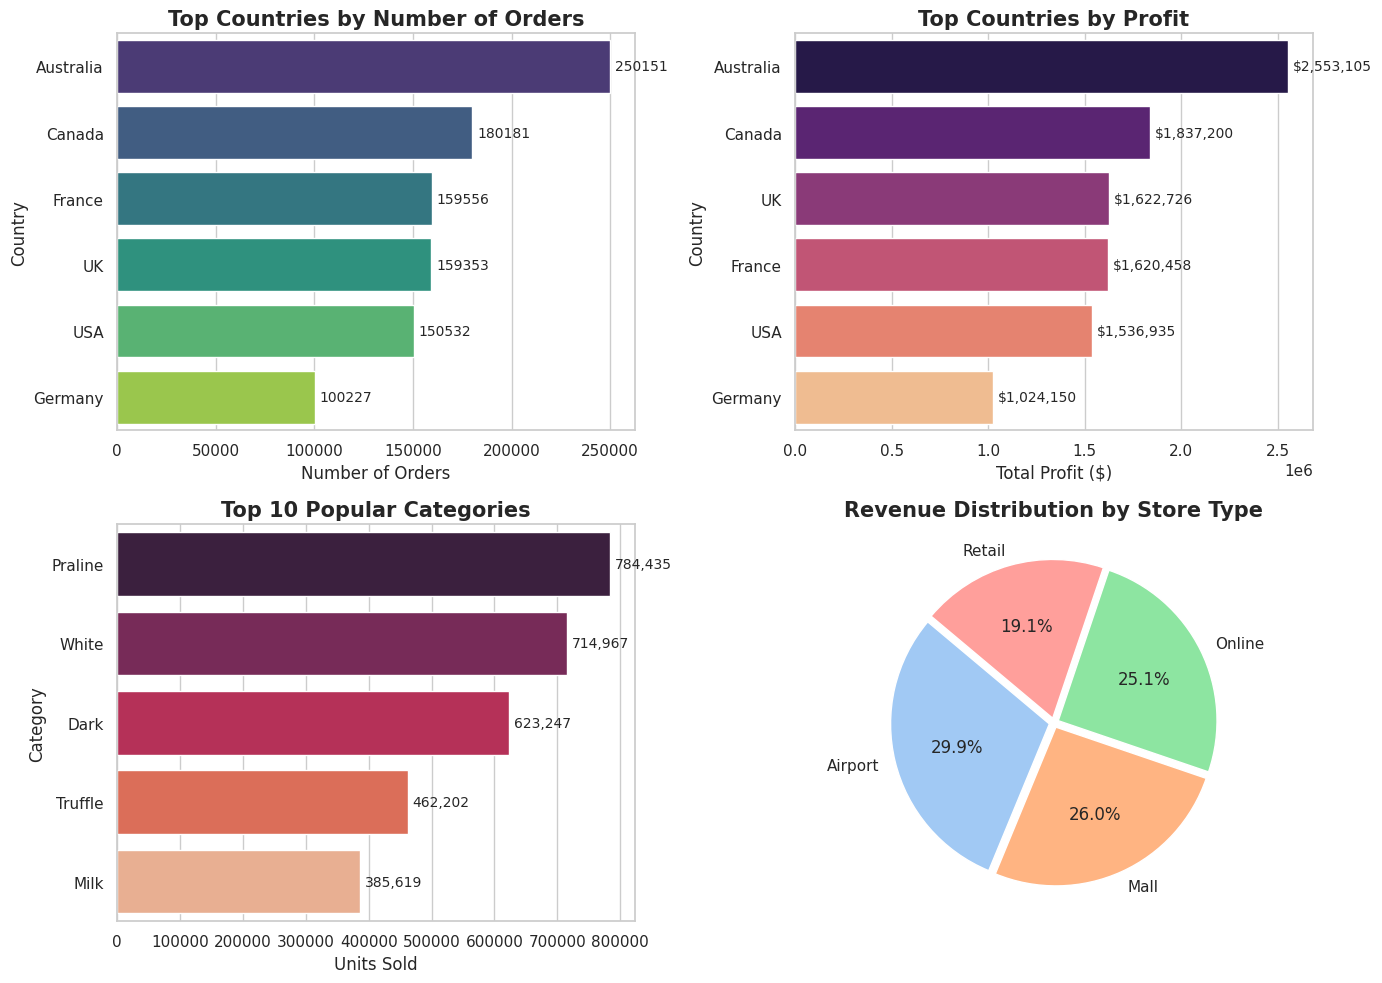

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style and canvas settings
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# --- CHART 1: Top Countries by Number of Orders ---
top_orders = data.groupby('country')['order_id'].nunique().sort_values(ascending=False).head(10)
sns.barplot(x=top_orders.values, y=top_orders.index, ax=axes[0, 0], hue=top_orders.index, palette='viridis', legend=False)
axes[0, 0].set_title('Top Countries by Number of Orders', fontsize=15, fontweight='bold')
axes[0, 0].set_xlabel('Number of Orders')
axes[0, 0].set_ylabel('Country')

# Додаємо цифри: прибрано жирність (bold), зменшено розмір (fontsize=10)
for i, v in enumerate(top_orders.values):
    axes[0, 0].text(v + (top_orders.max()*0.01), i, f'{int(v)}', va='center', fontsize=10)

# --- CHART 2: Top Countries by Profit ---
top_profit = data.groupby('country')['profit'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_profit.values, y=top_profit.index, ax=axes[0, 1], hue=top_profit.index, palette='magma', legend=False)
axes[0, 1].set_title('Top Countries by Profit', fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel('Total Profit ($)')
axes[0, 1].set_ylabel('Country')

# Додаємо цифри: прибрано жирність, зменшено розмір
for i, v in enumerate(top_profit.values):
    axes[0, 1].text(v + (top_profit.max()*0.01), i, f'${v:,.0f}', va='center', fontsize=10)

# --- CHART 3: Top 10 Popular Categories ---
top_cats = data.groupby('category')['quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[1, 0], hue=top_cats.index, palette='rocket', legend=False)
axes[1, 0].set_title('Top 10 Popular Categories', fontsize=15, fontweight='bold')
axes[1, 0].set_xlabel('Units Sold')
axes[1, 0].set_ylabel('Category')

# Додаємо цифри: прибрано жирність, зменшено розмір
for i, v in enumerate(top_cats.values):
    axes[1, 0].text(v + (top_cats.max()*0.01), i, f'{int(v):,}', va='center', fontsize=10)

# --- CHART 4: Revenue Distribution by Store Type ---
store_type_dist = data.groupby('store_type')['revenue'].sum()
axes[1, 1].pie(store_type_dist, labels=store_type_dist.index, autopct='%1.1f%%',
               startangle=140, colors=sns.color_palette('pastel'), explode=[0.03]*len(store_type_dist))
axes[1, 1].set_title('Revenue Distribution by Store Type', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

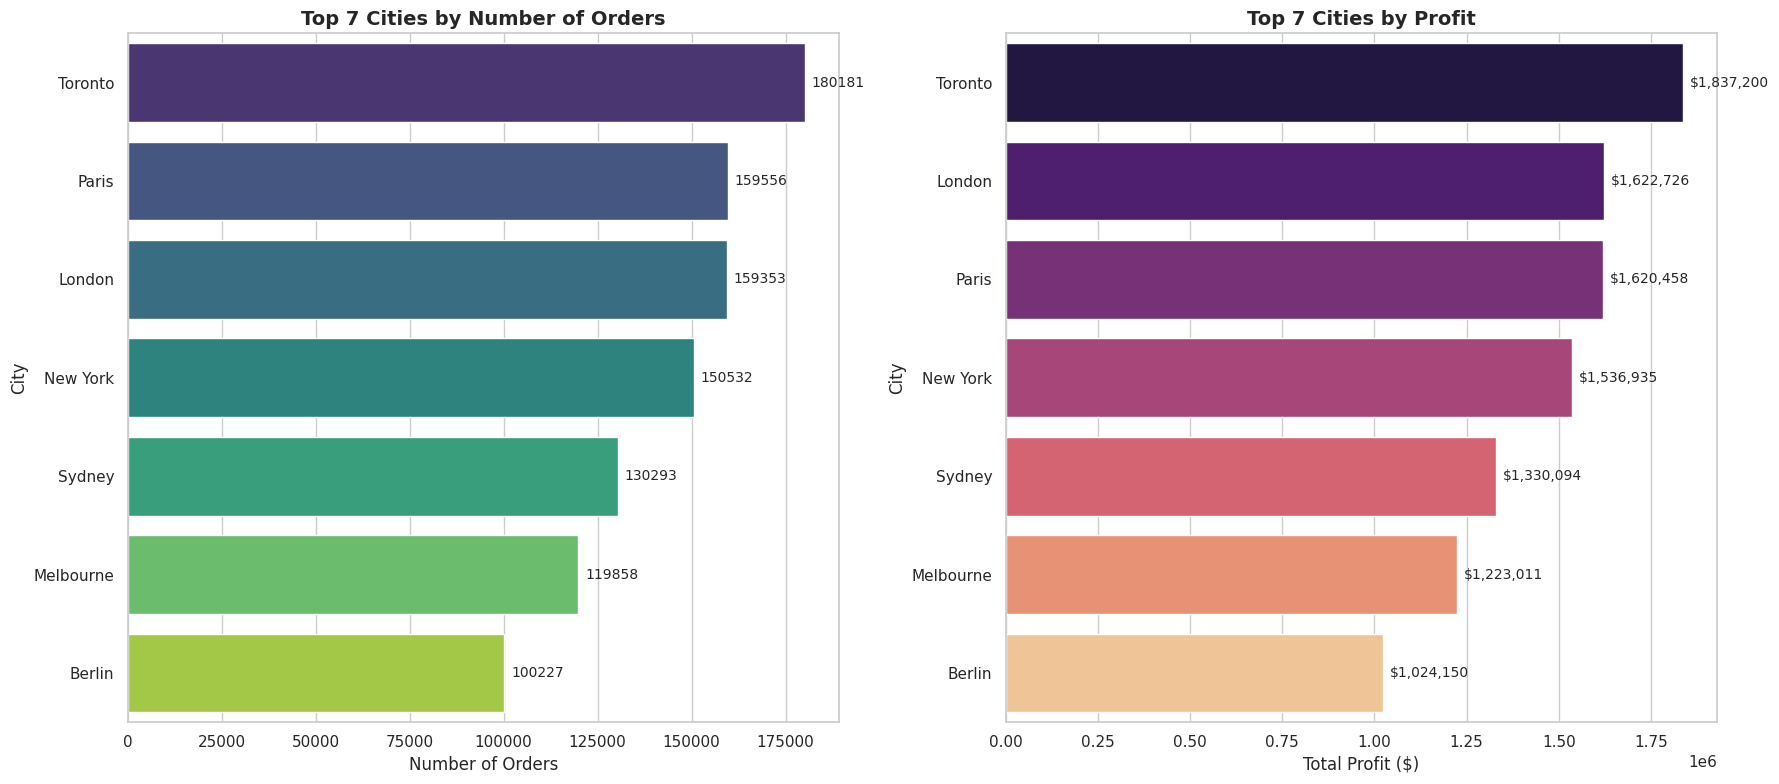

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.4)

# --- CHART 1: Top Cities by Number of Orders ---

top_cities_orders = data.groupby('city')['order_id'].nunique().sort_values(ascending=False).head(7)
sns.barplot(x=top_cities_orders.values, y=top_cities_orders.index, ax=axes[0], hue=top_cities_orders.index, palette='viridis', legend=False)
axes[0].set_title('Top 7 Cities by Number of Orders', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('City')


for i, v in enumerate(top_cities_orders.values):
    axes[0].text(v + (top_cities_orders.max()*0.01), i, f'{int(v)}', va='center', fontsize=10)

# --- CHART 2: Top Cities by Profit ---

top_cities_profit = data.groupby('city')['profit'].sum().sort_values(ascending=False).head(7)
sns.barplot(x=top_cities_profit.values, y=top_cities_profit.index, ax=axes[1], hue=top_cities_profit.index, palette='magma', legend=False)
axes[1].set_title('Top 7 Cities by Profit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_ylabel('City')


for i, v in enumerate(top_cities_profit.values):
    axes[1].text(v + (top_cities_profit.max()*0.01), i, f'${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

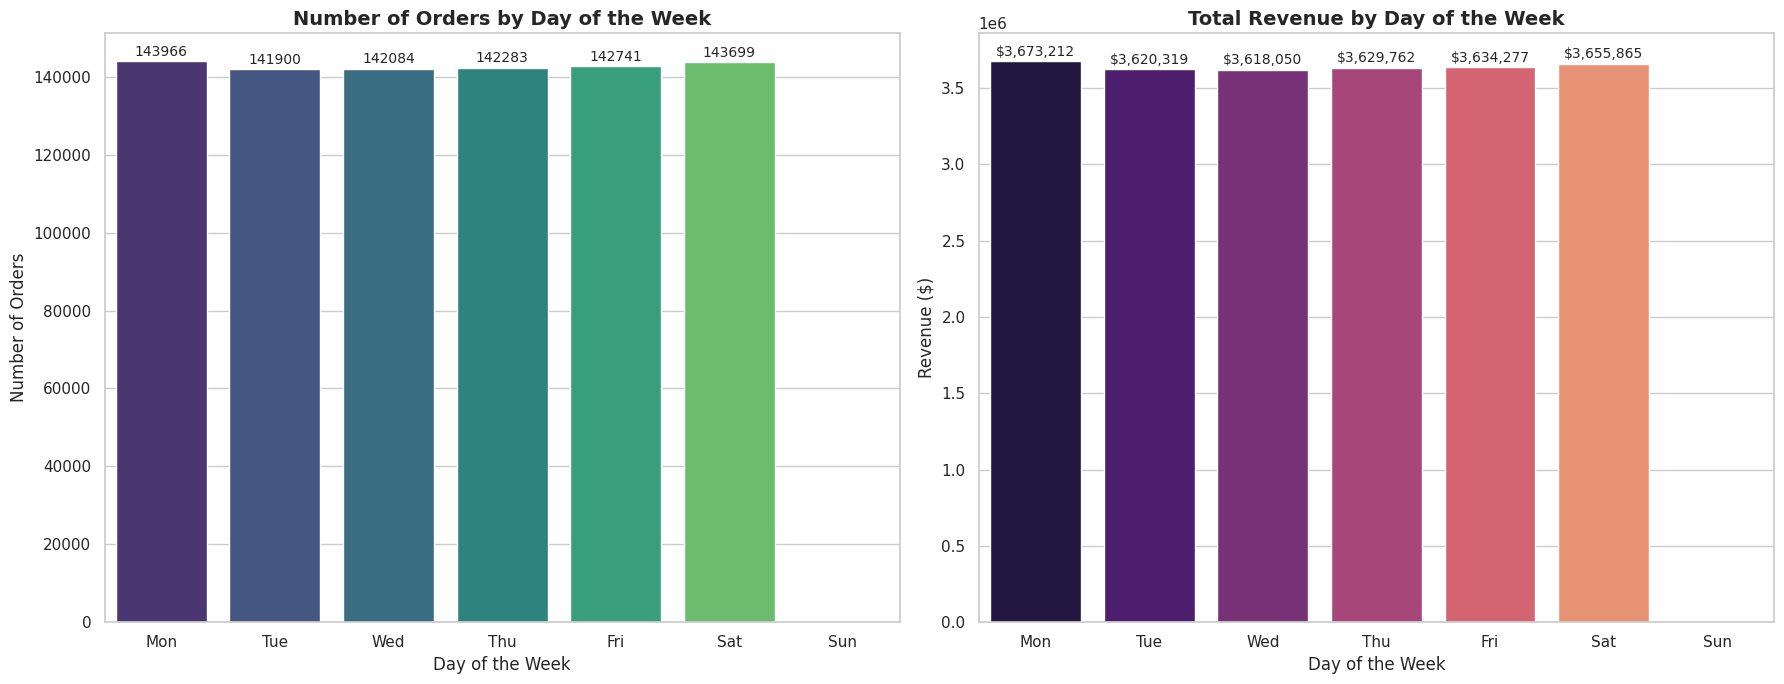

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.subplots_adjust(wspace=0.3)


day_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

data['day_name'] = data['day_of_week'].map(day_labels)

# --- CHART 1: Number of Orders by Day of the Week ---
orders_by_day = data.groupby('day_name')['order_id'].nunique().reindex(day_order)

sns.barplot(x=orders_by_day.index, y=orders_by_day.values, ax=axes[0], hue=orders_by_day.index, palette='viridis', legend=False)
axes[0].set_title('Number of Orders by Day of the Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Number of Orders')


for i, v in enumerate(orders_by_day.values):
    if pd.notnull(v):
        axes[0].text(i, v + (orders_by_day.max()*0.01), f'{int(v)}', ha='center', fontsize=10)

# --- CHART 2: Revenue by Day of the Week ---
revenue_by_day = data.groupby('day_name')['revenue'].sum().reindex(day_order)

sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, ax=axes[1], hue=revenue_by_day.index, palette='magma', legend=False)
axes[1].set_title('Total Revenue by Day of the Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of the Week')
axes[1].set_ylabel('Revenue ($)')


for i, v in enumerate(revenue_by_day.values):
    if pd.notnull(v):
        axes[1].text(i, v + (revenue_by_day.max()*0.01), f'${v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

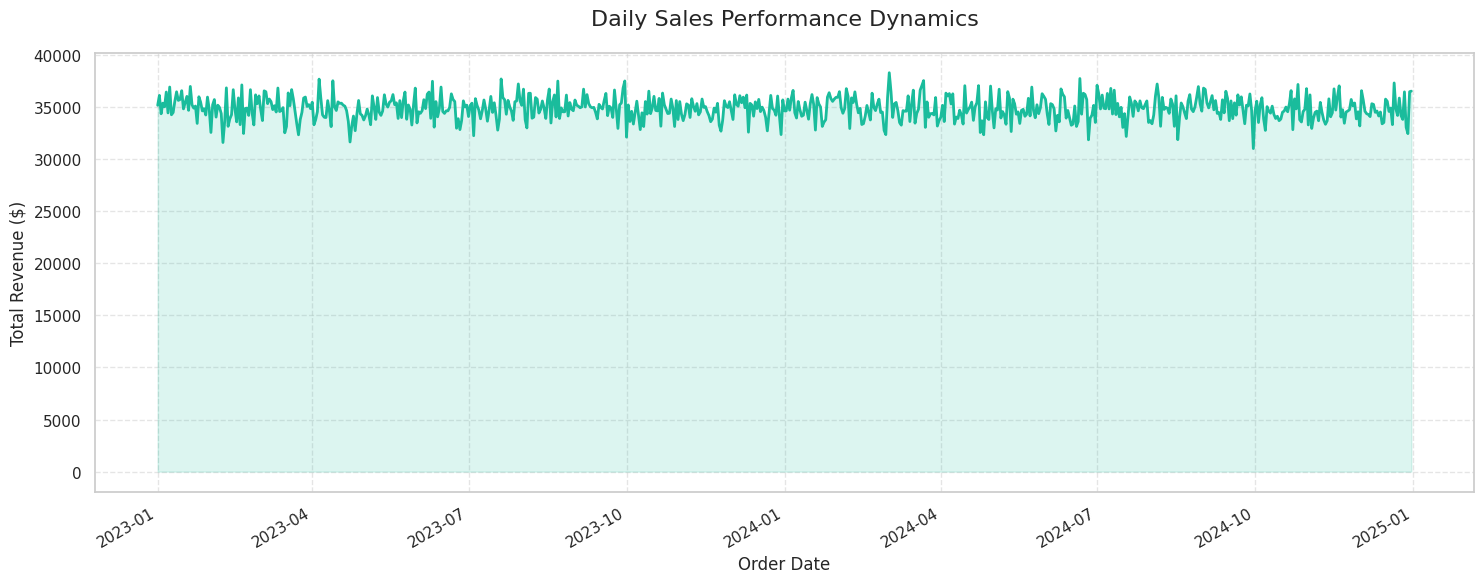

Top 5 Dates by Highest Revenue:
    order_date   revenue
426 2024-03-02  38294.01
537 2024-06-21  37736.36
200 2023-07-20  37696.04
94  2023-04-05  37679.63
446 2024-03-22  37539.76


In [ ]:

# 1. Group data by date and sum the revenue
daily_sales = data.groupby("order_date")["revenue"].sum().reset_index()

# 2. Create the visualization
plt.figure(figsize=(15, 6))

# Plot the line chart
sns.lineplot(data=daily_sales, x="order_date", y="revenue", color="#1ABC9C", linewidth=2)

# Fill the area under the plot for better visual depth
plt.fill_between(daily_sales["order_date"], daily_sales["revenue"], color="#1ABC9C", alpha=0.15)

# Add titles and labels in English
plt.title("Daily Sales Performance Dynamics", fontsize=16, pad=20)
plt.xlabel("Order Date", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Automatically format X-axis dates to prevent overlapping
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# 3. Display Top 5 most successful days for quick analysis
print("Top 5 Dates by Highest Revenue:")
print(daily_sales.sort_values(by="revenue", ascending=False).head(5))

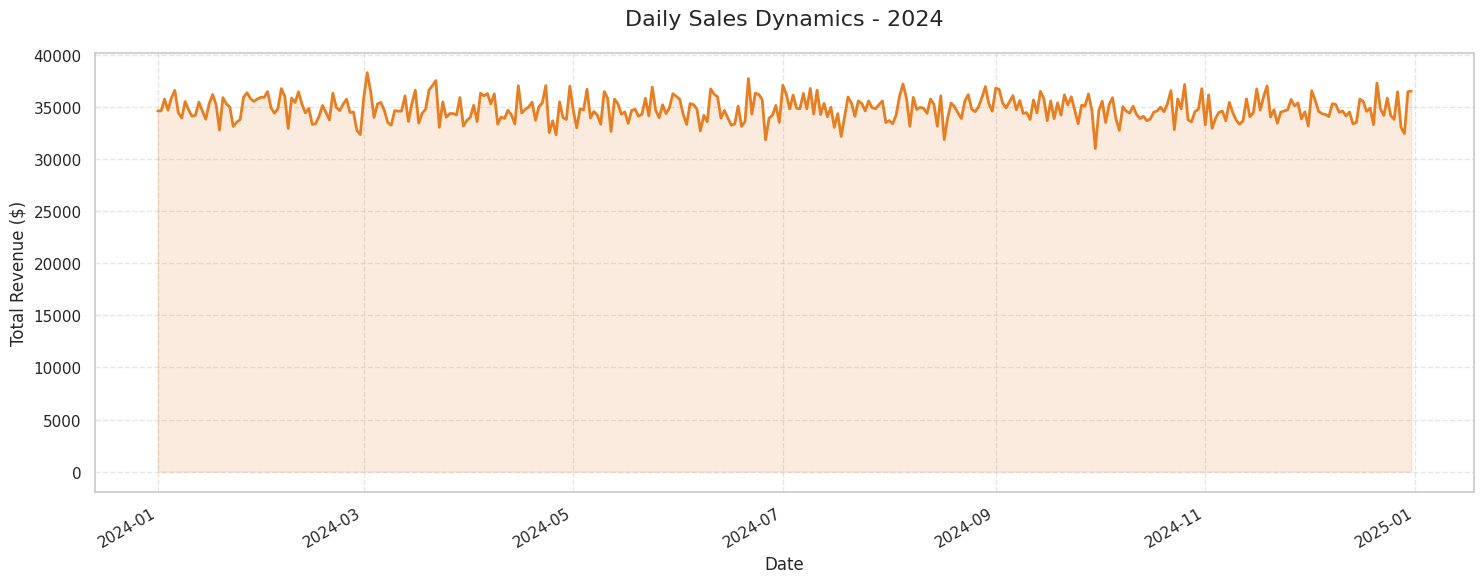

Top 5 Dates in 2024 by Highest Revenue:
    order_date   revenue
61  2024-03-02  38294.01
172 2024-06-21  37736.36
81  2024-03-22  37539.76
355 2024-12-21  37311.49
217 2024-08-05  37209.42


In [ ]:


# 1. Ensure the date column is in datetime format
data['order_date'] = pd.to_datetime(data['order_date'])

# 2. Filter data specifically for the year 2024
data_2024 = data[data['order_date'].dt.year == 2024].copy()

# 3. Group by date and sum the revenue for 2024
daily_sales_2024 = data_2024.groupby("order_date")["revenue"].sum().reset_index()

# 4. Create the visualization
plt.figure(figsize=(15, 6))

# Plot the line chart (using a different color to distinguish 2024)
sns.lineplot(data=daily_sales_2024, x="order_date", y="revenue", color="#E67E22", linewidth=2)

# Fill the area under the plot
plt.fill_between(daily_sales_2024["order_date"], daily_sales_2024["revenue"], color="#E67E22", alpha=0.15)

# Add titles and labels
plt.title("Daily Sales Dynamics - 2024", fontsize=16, pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Format dates on X-axis
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# 5. Display Top 5 most successful days in 2024
print("Top 5 Dates in 2024 by Highest Revenue:")
print(daily_sales_2024.sort_values(by="revenue", ascending=False).head(5))

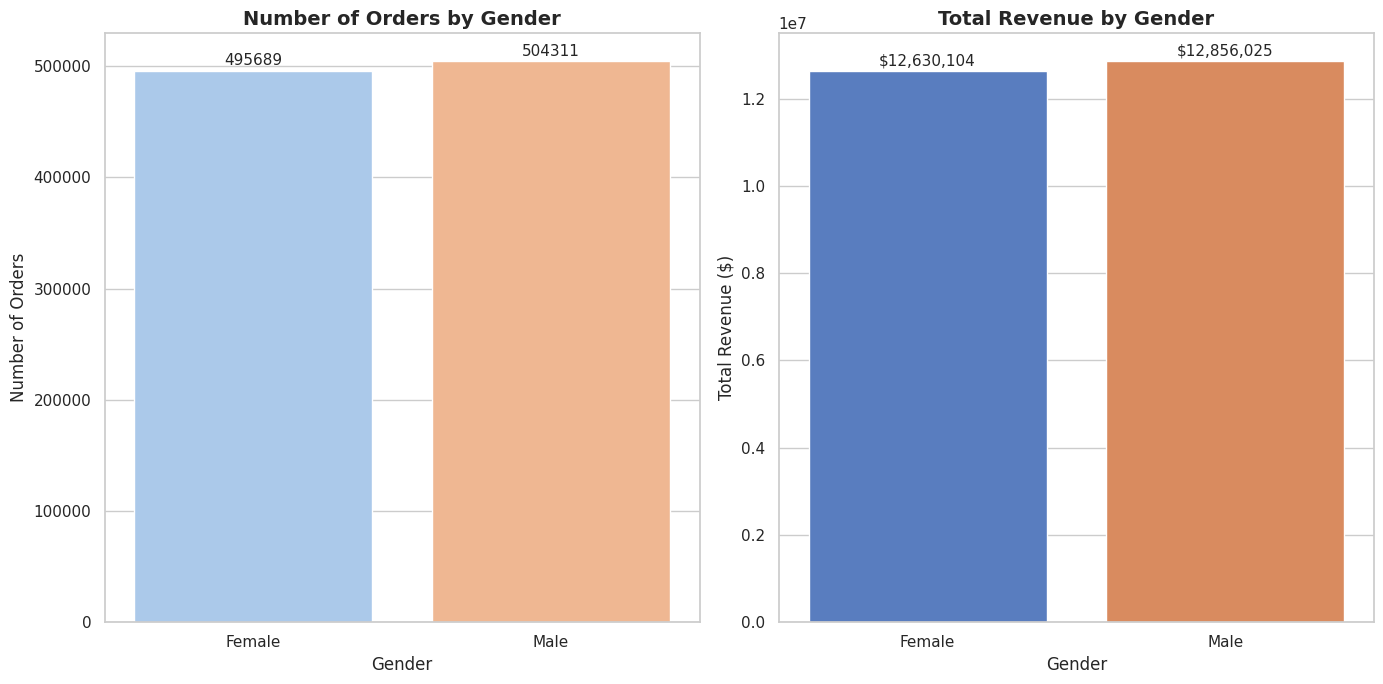

In [ ]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plt.subplots_adjust(wspace=0.3)

# --- CHART 1: Number of Orders by Gender ---
orders_by_gender = data.groupby('gender')['order_id'].nunique()

sns.barplot(x=orders_by_gender.index, y=orders_by_gender.values, ax=axes[0], hue=orders_by_gender.index, palette='pastel', legend=False)
axes[0].set_title('Number of Orders by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Orders')


for i, v in enumerate(orders_by_gender.values):
    axes[0].text(i, v + (orders_by_gender.max()*0.01), f'{int(v)}', ha='center', fontsize=11)

# --- CHART 2: Total Revenue by Gender ---
revenue_by_gender = data.groupby('gender')['revenue'].sum()

sns.barplot(x=revenue_by_gender.index, y=revenue_by_gender.values, ax=axes[1], hue=revenue_by_gender.index, palette='muted', legend=False)
axes[1].set_title('Total Revenue by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Total Revenue ($)')


for i, v in enumerate(revenue_by_gender.values):
    axes[1].text(i, v + (revenue_by_gender.max()*0.01), f'${v:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

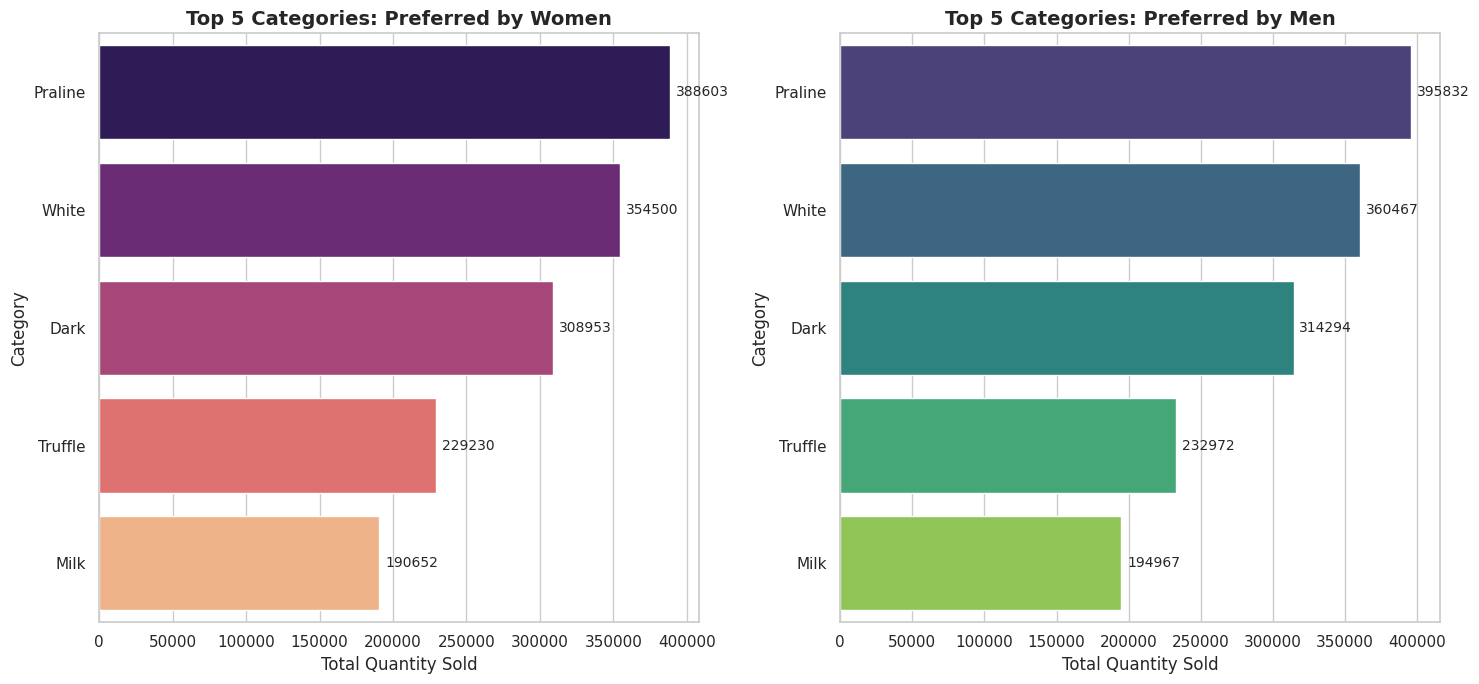

In [ ]:
gender_products = data.groupby(['gender', 'category'])['quantity'].sum().reset_index()

top_women = gender_products[gender_products['gender'] == 'Female'].sort_values(by='quantity', ascending=False).head(5)
top_men = gender_products[gender_products['gender'] == 'Male'].sort_values(by='quantity', ascending=False).head(5)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
plt.subplots_adjust(wspace=0.4)

sns.barplot(x='quantity', y='category', data=top_women, ax=axes[0], hue='category', palette='magma', legend=False)
axes[0].set_title('Top 5 Categories: Preferred by Women', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Quantity Sold')
axes[0].set_ylabel('Category')

for i, v in enumerate(top_women['quantity']):
    axes[0].text(v + (top_women['quantity'].max()*0.01), i, f'{int(v)}', va='center', fontsize=10)

sns.barplot(x='quantity', y='category', data=top_men, ax=axes[1], hue='category', palette='viridis', legend=False)
axes[1].set_title('Top 5 Categories: Preferred by Men', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Quantity Sold')
axes[1].set_ylabel('Category')

for i, v in enumerate(top_men['quantity']):
    axes[1].text(v + (top_men['quantity'].max()*0.01), i, f'{int(v)}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

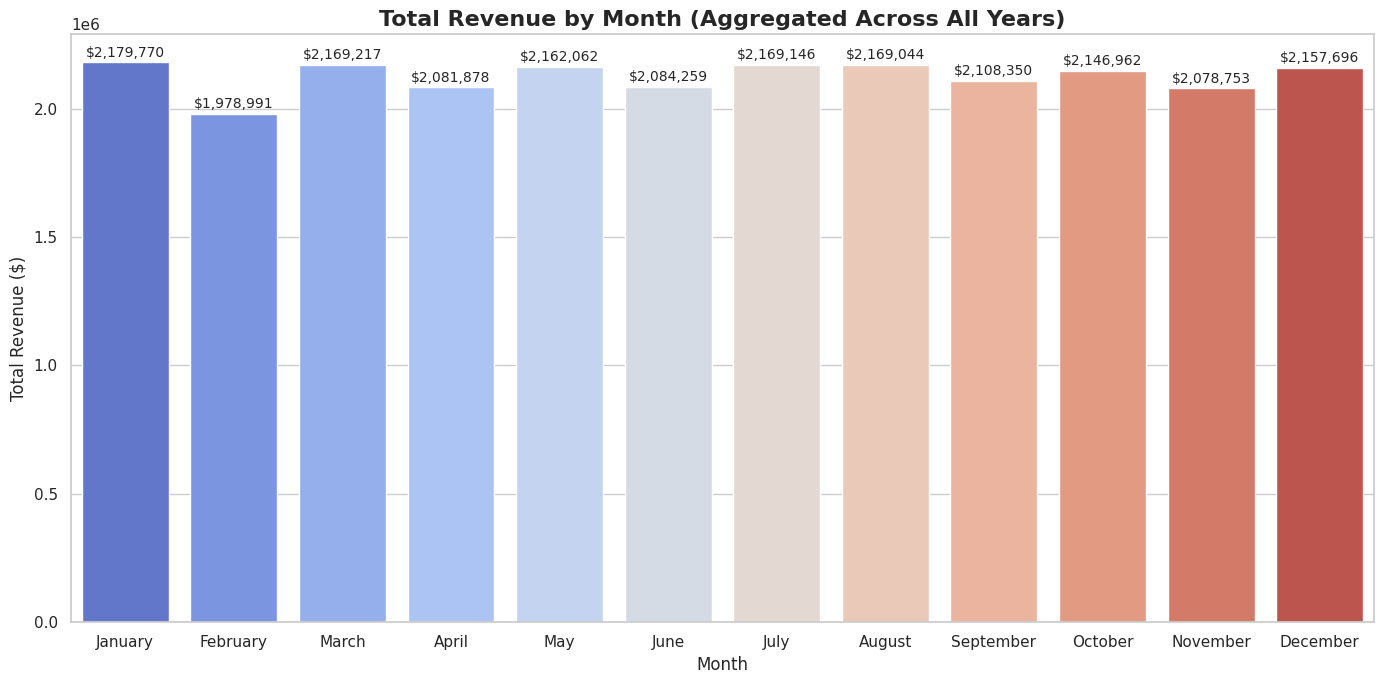

Monthly Revenue Ranking:
   month_name     revenue
0     January  2179770.20
2       March  2169216.91
6        July  2169146.47
7      August  2169043.54
4         May  2162061.97
11   December  2157696.03
9     October  2146961.85
8   September  2108349.78
5        June  2084259.26
3       April  2081878.46
10   November  2078753.22
1    February  1978991.17


In [ ]:
# 1. Ensure date format
data['order_date'] = pd.to_datetime(data['order_date'])

# 2. Extract month number and month name
data['month_num'] = data['order_date'].dt.month
data['month_name'] = data['order_date'].dt.strftime('%B')

# 3. Group by month (keeping numerical order) and sum revenue
monthly_sales = data.groupby(['month_num', 'month_name'])['revenue'].sum().reset_index().sort_values('month_num')

# 4. Create visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

sns.barplot(x='month_name', y='revenue', data=monthly_sales, hue='month_name', palette='coolwarm', legend=False)

plt.title('Total Revenue by Month (Aggregated Across All Years)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Adding small, non-bold labels with currency formatting
for i, v in enumerate(monthly_sales['revenue']):
    plt.text(i, v + (monthly_sales['revenue'].max() * 0.01), f'${v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Display ranking for analysis
print("Monthly Revenue Ranking:")
print(monthly_sales[['month_name', 'revenue']].sort_values(by='revenue', ascending=False))

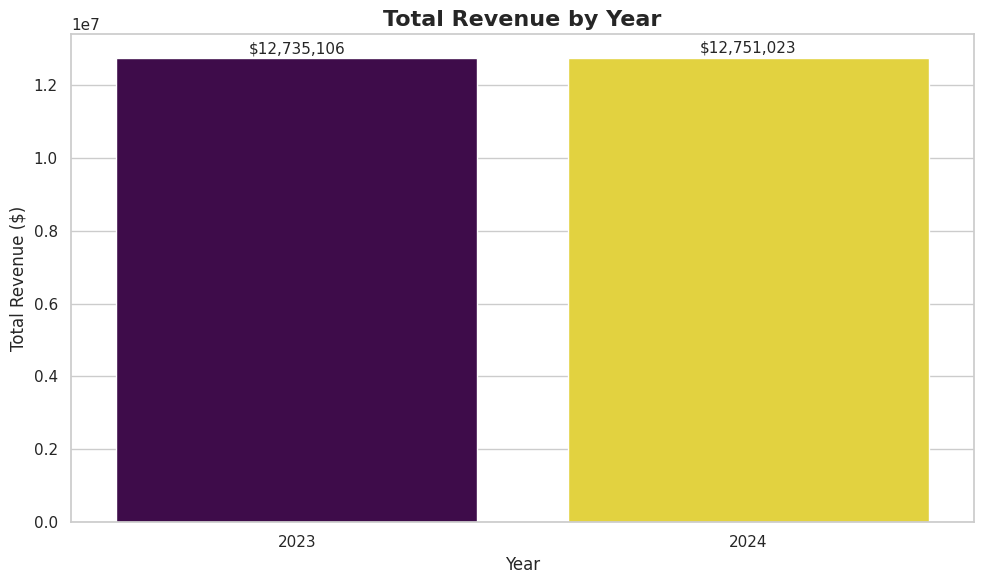

Yearly Revenue and Growth (%):
   year      revenue  growth_pct
0  2023  12735106.27         NaN
1  2024  12751022.59     0.12498


In [ ]:
#  Group by year and sum revenue
yearly_sales = data.groupby('year')['revenue'].sum().reset_index()

#  Create visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plotting annual revenue
sns.barplot(x='year', y='revenue', data=yearly_sales, hue='year', palette='viridis', legend=False)

plt.title('Total Revenue by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Adding small, non-bold labels with currency formatting
for i, v in enumerate(yearly_sales['revenue']):
    plt.text(i, v + (yearly_sales['revenue'].max() * 0.01), f'${v:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

#  Show results with year-over-year growth
yearly_sales['growth_pct'] = yearly_sales['revenue'].pct_change() * 100
print("Yearly Revenue and Growth (%):")
print(yearly_sales)

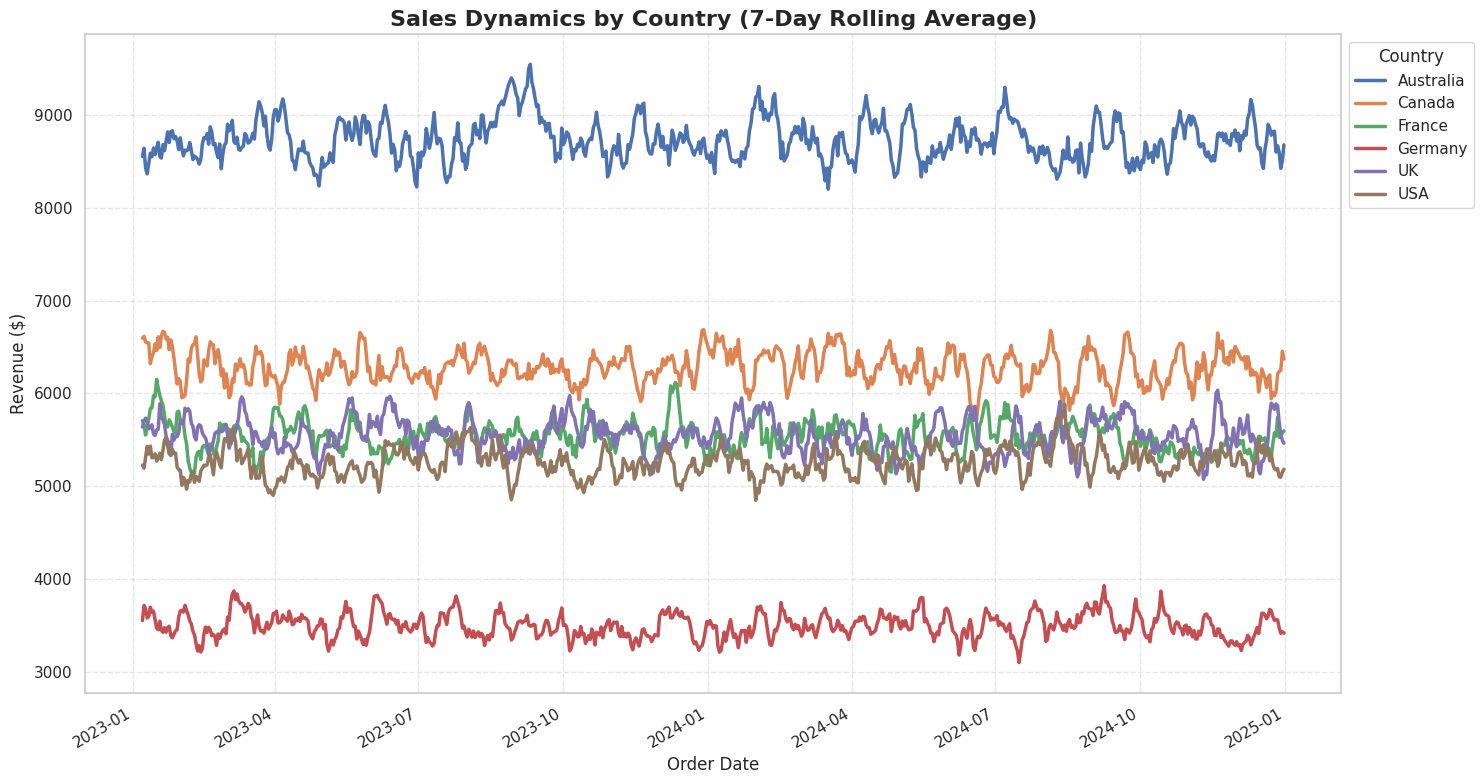

Total Revenue by Country:
country
Australia    6381601.52
Canada       4593793.59
UK           4059812.16
France       4049366.83
USA          3842643.97
Germany      2558910.79
Name: revenue, dtype: float64


In [ ]:
# 1. Ensure date format and sort by date
data['order_date'] = pd.to_datetime(data['order_date'])
data = data.sort_values('order_date')

# 2. Create a pivot table: Rows = Dates, Columns = Continents, Values = Revenue
country_dynamics = data.pivot_table(
    index='order_date',
    columns='country',
    values='revenue',
    aggfunc='sum'
).fillna(0)

# 3. Apply 7-day rolling mean to smooth the lines for better trend visibility
country_smooth = country_dynamics.rolling(window=7).mean()

# 4. Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8))

# Plotting each country
for country in country_smooth.columns:
    sns.lineplot(data=country_smooth, x=country_smooth.index, y=country, label=country, linewidth=2.5)

plt.title('Sales Dynamics by Country (7-Day Rolling Average)', fontsize=16, fontweight='bold')
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(title='Country', title_fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle="--", alpha=0.5)

# Format dates on X-axis
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# 5. Display total revenue summary by country
print("Total Revenue by Country:")
print(data.groupby('country')['revenue'].sum().sort_values(ascending=False))

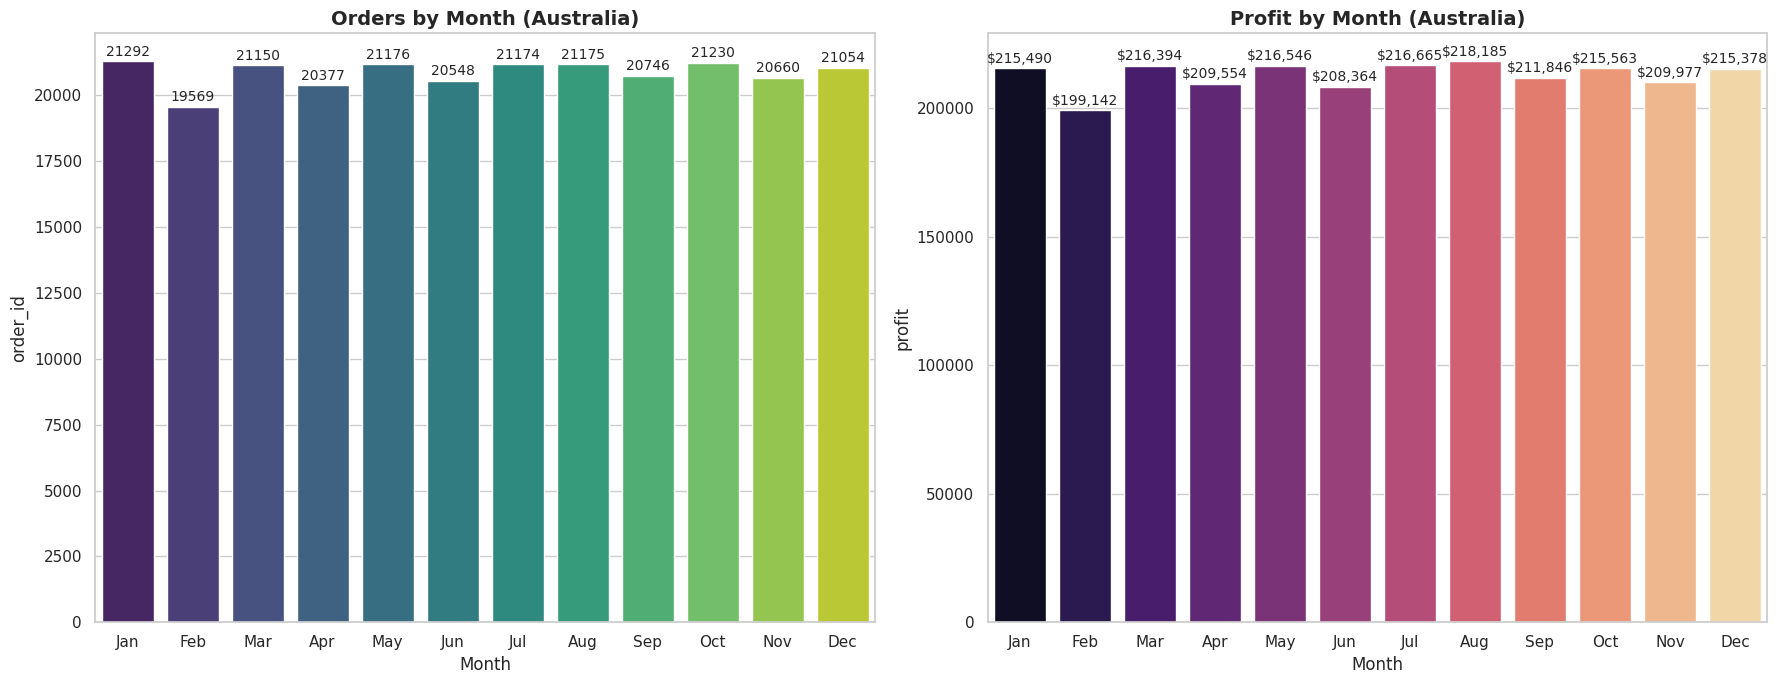

In [ ]:

aus_data = data[data['country'] == 'Australia'].copy()


aus_monthly = aus_data.groupby('month').agg({
    'order_id': 'nunique',
    'profit': 'sum'
}).reset_index()


month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
aus_monthly['month_label'] = aus_monthly['month'].map(month_map)


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))


sns.barplot(data=aus_monthly, x='month_label', y='order_id', palette='viridis', ax=axes[0], hue='month_label', legend=False)
axes[0].set_title('Orders by Month (Australia)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')

for i, v in enumerate(aus_monthly['order_id']):
    axes[0].text(i, v + (aus_monthly['order_id'].max()*0.01), f'{int(v)}', ha='center', fontsize=10)


sns.barplot(data=aus_monthly, x='month_label', y='profit', palette='magma', ax=axes[1], hue='month_label', legend=False)
axes[1].set_title('Profit by Month (Australia)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')

for i, v in enumerate(aus_monthly['profit']):
    axes[1].text(i, v + (aus_monthly['profit'].max()*0.01), f'${v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

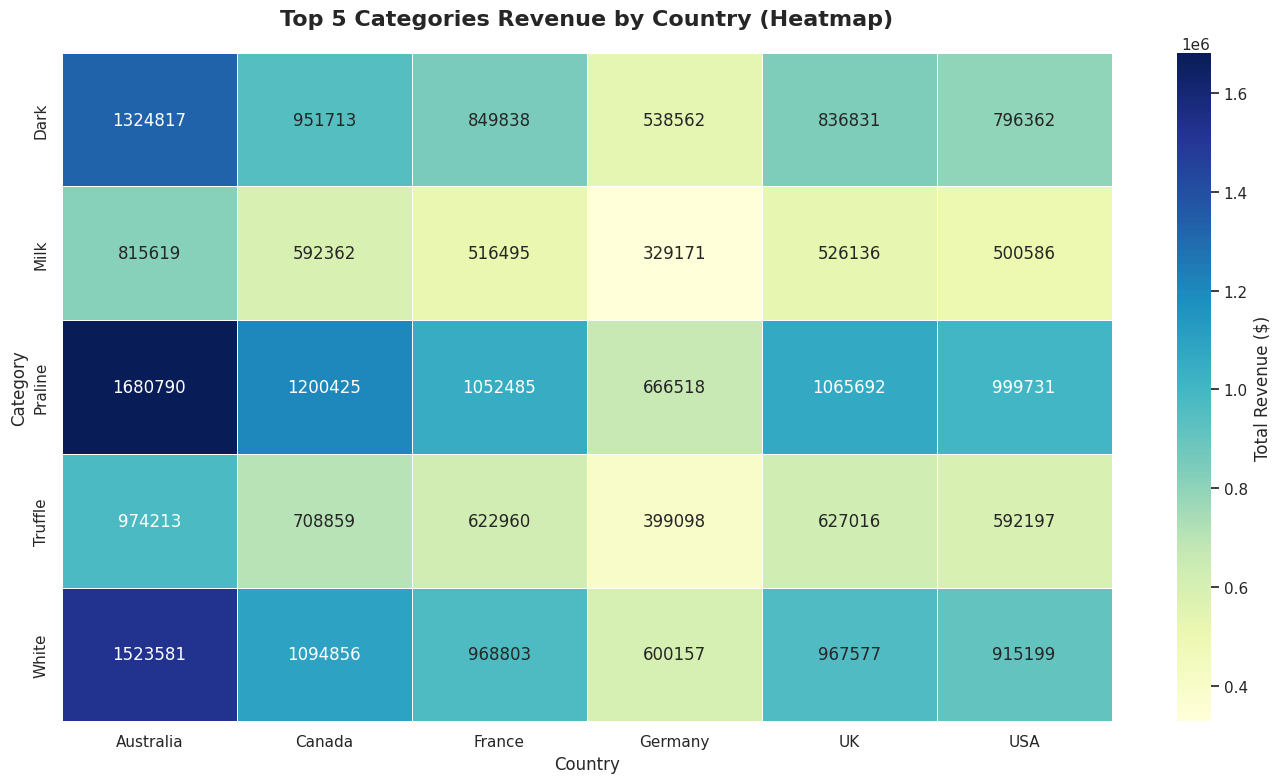

Top 5 Categories by Country (Summary Table):
country    Australia      Canada      France    Germany          UK        USA
category                                                                      
Dark      1324817.26   951712.59   849838.06  538561.98   836831.09  796362.29
Milk       815618.97   592361.59   516494.84  329171.27   526135.80  500585.72
Praline   1680790.09  1200425.01  1052485.04  666517.62  1065692.45  999731.11
Truffle    974212.95   708859.22   622959.77  399097.99   627016.31  592197.00
White     1523581.18  1094856.40   968802.63  600156.53   967576.62  915198.84


In [ ]:
top_categories = data.groupby('category')['revenue'].sum().sort_values(ascending=False).head(5).index


filtered_data = data[data['category'].isin(top_categories)]

# (Pivot Table)

heatmap_data = filtered_data.pivot_table(
    index='category',
    columns='country',
    values='revenue',
    aggfunc='sum'
).fillna(0)

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Total Revenue ($)'}
)

plt.title('Top 5 Categories Revenue by Country (Heatmap)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.tight_layout()
plt.show()


print("Top 5 Categories by Country (Summary Table):")
print(heatmap_data)

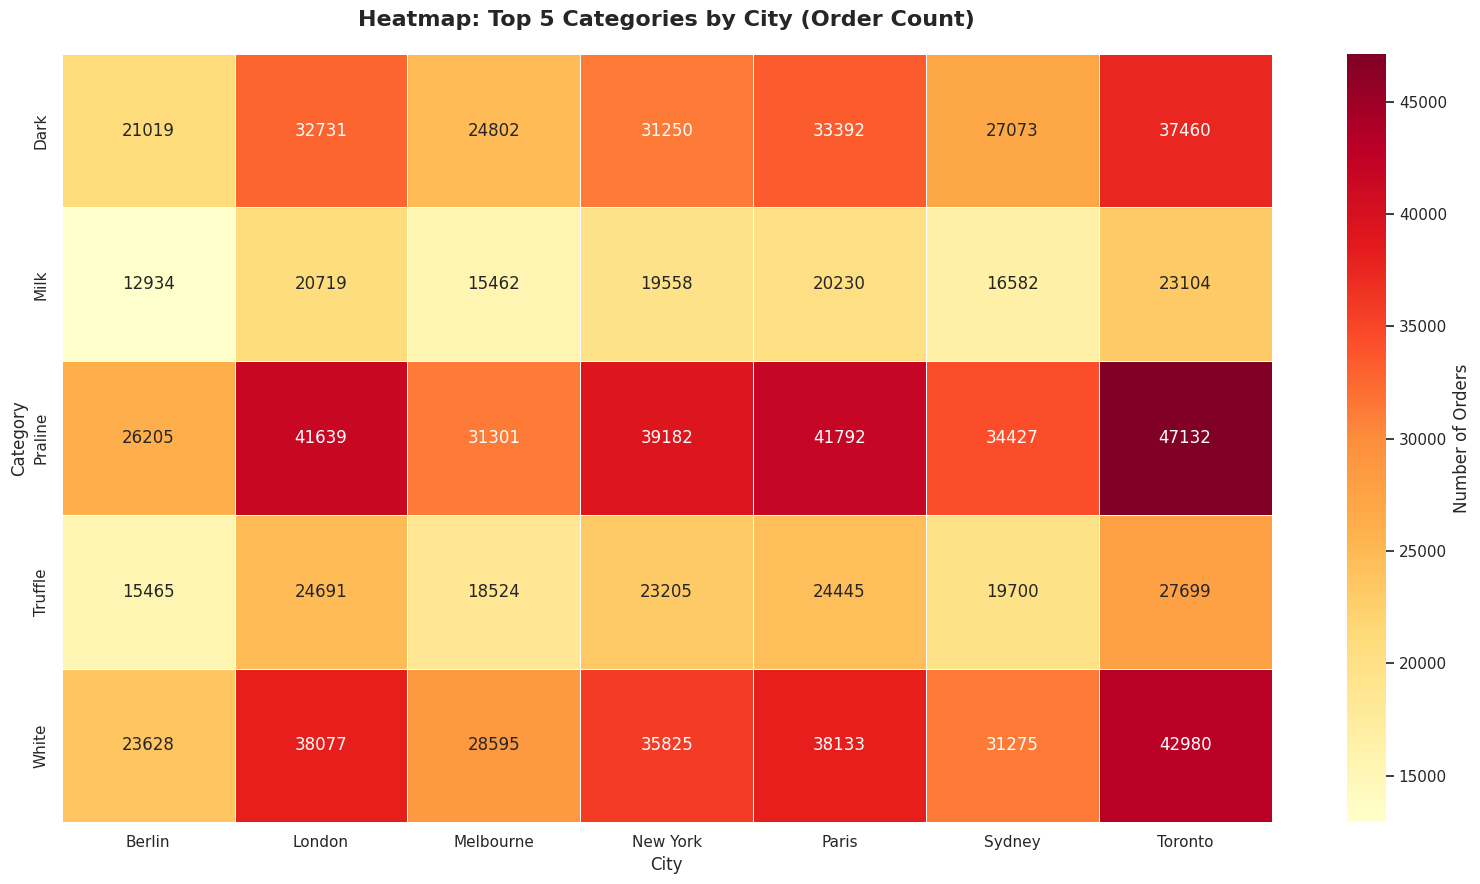

Pivot Table: Top 5 Categories by City (Order Count)
city      Berlin  London  Melbourne  New York  Paris  Sydney  Toronto
category                                                             
Dark       21019   32731      24802     31250  33392   27073    37460
Milk       12934   20719      15462     19558  20230   16582    23104
Praline    26205   41639      31301     39182  41792   34427    47132
Truffle    15465   24691      18524     23205  24445   19700    27699
White      23628   38077      28595     35825  38133   31275    42980


In [ ]:
top_categories_orders = data.groupby('category')['order_id'].nunique().sort_values(ascending=False).head(5).index


filtered_orders = data[data['category'].isin(top_categories_orders)]


pivot_orders = filtered_orders.pivot_table(
    index='category',
    columns='city',
    values='order_id',
    aggfunc='nunique'
).fillna(0)

# Heatmap
plt.figure(figsize=(16, 9))
sns.heatmap(
    pivot_orders,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=.5,
    cbar_kws={'label': 'Number of Orders'}
)

plt.title('Heatmap: Top 5 Categories by City (Order Count)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.tight_layout()
plt.show()


print("Pivot Table: Top 5 Categories by City (Order Count)")
print(pivot_orders)

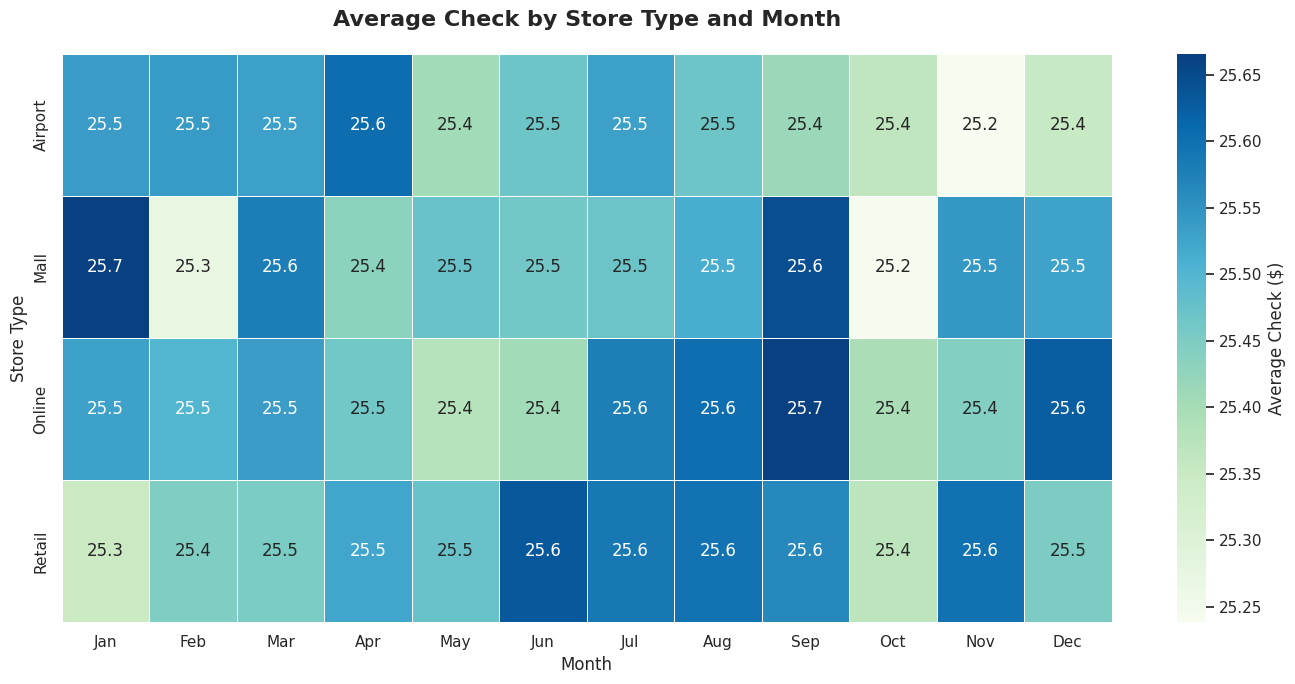

Average Check by Store Type (Table):
                  Jan        Feb        Mar        Apr        May        Jun  \
store_type                                                                     
Airport     25.534625  25.538087  25.530474  25.605343  25.406576  25.467996   
Mall        25.665644  25.273570  25.579423  25.433309  25.473022  25.460785   
Online      25.528787  25.499254  25.535142  25.462875  25.376501  25.405975   
Retail      25.347845  25.446973  25.453147  25.522580  25.472144  25.630834   

                  Jul        Aug        Sep        Oct        Nov        Dec  
store_type                                                                    
Airport     25.530628  25.468290  25.415011  25.365026  25.238184  25.351784  
Mall        25.469682  25.513564  25.645811  25.244080  25.542810  25.528673  
Online      25.577371  25.603370  25.664892  25.393770  25.442046  25.624407  
Retail      25.587366  25.594945  25.564261  25.369303  25.597486  25.451723  


In [ ]:

grouped_data = data.groupby(['store_type', 'month']).agg({
    'revenue': 'sum',
    'order_id': 'nunique'
}).reset_index()

# 2. Розраховуємо середній чек
grouped_data['avg_check'] = grouped_data['revenue'] / grouped_data['order_id']


pivot_avg_check = grouped_data.pivot_table(
    index='store_type',
    columns='month',
    values='avg_check'
).fillna(0)


month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
pivot_avg_check.columns = [month_map.get(m, m) for m in pivot_avg_check.columns]

# Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot_avg_check,
    annot=True,
    fmt=".1f",
    cmap="GnBu",
    linewidths=.5,
    cbar_kws={'label': 'Average Check ($)'}
)

plt.title('Average Check by Store Type and Month', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Store Type', fontsize=12)

plt.tight_layout()
plt.show()


print("Average Check by Store Type (Table):")
print(pivot_avg_check)

##Statistical part

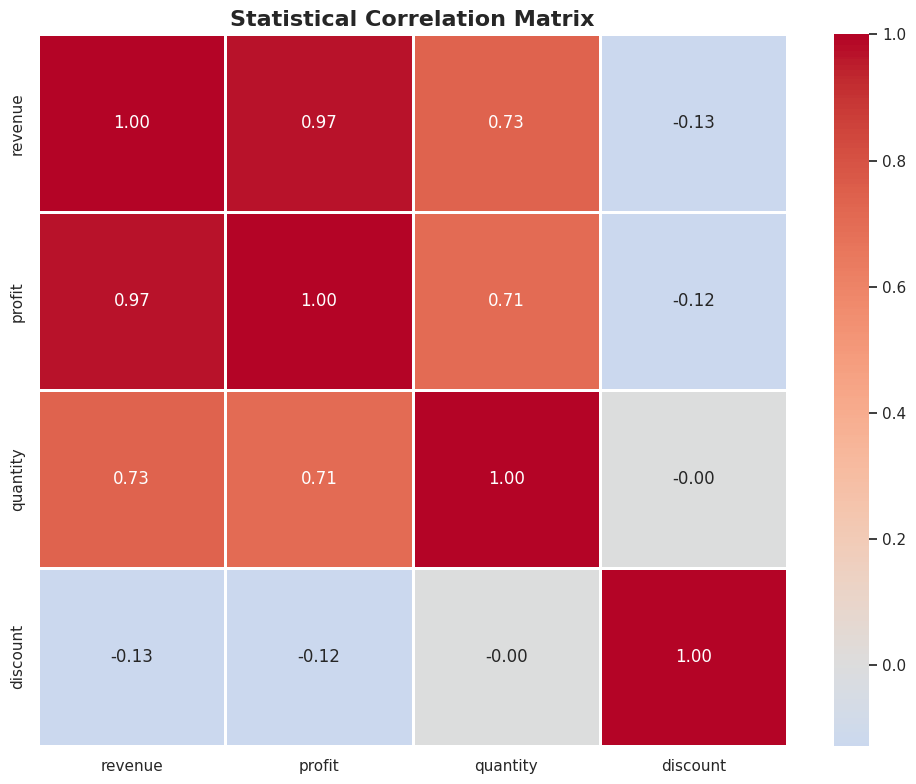

Коефіцієнти кореляції:
           revenue    profit  quantity  discount
revenue   1.000000  0.966184  0.733962 -0.127252
profit    0.966184  1.000000  0.709028 -0.123258
quantity  0.733962  0.709028  1.000000 -0.000147
discount -0.127252 -0.123258 -0.000147  1.000000


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


numeric_cols = ['revenue', 'profit', 'quantity', 'discount']

df_numeric = data[numeric_cols]

corr_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=1)

plt.title('Statistical Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


print("Correlation coefficients:")
print(corr_matrix)

There is an exceptionally high positive correlation (0.97) between Revenue and Profit. This indicates a very stable profit margin, suggesting that as the business scales and sales volume increases, profitability follows consistently without significant loss of efficiency.


The correlation between Quantity and Revenue (0.73) is strong but notably lower than the Revenue-Profit link. This implies that total income is driven not just by the number of units sold, but significantly by the unit price or product mix (selling higher-value items).

A critical finding is the 0.00 correlation between Discount and Quantity. Statistically, this proves that increasing discounts does not lead to an increase in the number of items sold.

The negative correlation between Discount and Profit (-0.12) confirms that discounts are currently "value-destructive." They reduce the final profit margin without providing the intended "volume boost" to compensate for the lower price.

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# 1. Clean the data to remove any missing values for accurate testing
# Replace 'revenue' and 'profit' with your specific column names if different
clean_df = data[['revenue', 'profit']].dropna()

# 2. Calculate Pearson Correlation and P-value
# pearsonr returns: (correlation_coefficient, p_value)
correlation_coeff, p_value = pearsonr(clean_df['revenue'], clean_df['profit'])

# 3. Output the findings
print("--- Statistical Significance Analysis ---")
print(f"Pearson Correlation (r): {correlation_coeff:.4f}")
print(f"P-value: {p_value:.4e}")  # Scientific notation for high precision

# 4. Final Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"Status: Statistically Significant (p < {alpha})")
    print("Conclusion: There is strong evidence that the relationship between the variables is real and not due to random chance.")
else:
    print(f"Status: Not Statistically Significant (p >= {alpha})")
    print("Conclusion: The relationship is likely due to sampling noise or random variation.")

--- Statistical Significance Analysis ---
Pearson Correlation (r): 0.9662
P-value: 0.0000e+00
Status: Statistically Significant (p < 0.05)
Conclusion: There is strong evidence that the relationship between the variables is real and not due to random chance.


The Pearson correlation coefficient ($r$) of 0.9662 indicates an exceptionally strong positive linear relationship between the variables. This suggests that as one variable increases, the other increases in a highly predictable manner.
We can confidently reject the null hypothesis ($H_0$), which assumes no relationship exists. The probability that this correlation occurred by random chance is virtually non-existent.

This result provides a high level of confidence for data-driven decision-making. The variables are mathematically "locked" together, meaning strategies aimed at influencing one will almost certainly result in a corresponding change in the other.

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# 1. Identify Top 5 Countries by Sales (Revenue)
top_5_countries = data.groupby('country')['revenue'].sum().sort_values(ascending=False).head(5).index.tolist()

# 2. Perform Statistical Analysis for each country
stats_results = []

for country in top_5_countries:
    # Filter data for the specific country and drop missing values
    subset = data[data['country'] == country][['revenue', 'profit']].dropna()

    if len(subset) > 1:
        correlation, p_value = pearsonr(subset['revenue'], subset['profit'])

        stats_results.append({
            'Country': country,
            'Pearson (r)': round(correlation, 4),
            'P-value': f"{p_value:.4e}",
            'Significant (p < 0.05)': "Yes" if p_value < 0.05 else "No"
        })

# 3. Display the Results
results_df = pd.DataFrame(stats_results)
print(results_df.to_string(index=False))

  Country  Pearson (r)    P-value Significant (p < 0.05)
Australia       0.9662 0.0000e+00                    Yes
   Canada       0.9662 0.0000e+00                    Yes
       UK       0.9662 0.0000e+00                    Yes
   France       0.9663 0.0000e+00                    Yes
      USA       0.9661 0.0000e+00                    Yes


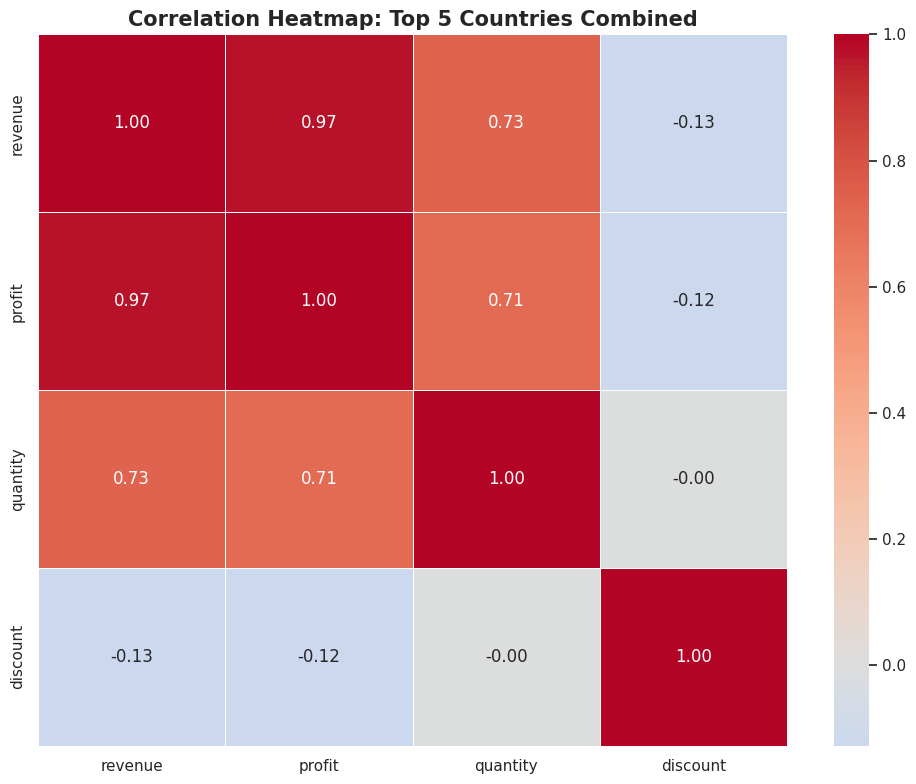

In [ ]:

# 1. ТОП-5
top_5_countries = data.groupby('country')['revenue'].sum().sort_values(ascending=False).head(5).index.tolist()

# 2. Filtration
top_5_df = data[data['country'].isin(top_5_countries)]

# 3 (Revenue, Profit, Quantity, Discount)
corr_matrix = top_5_df[['revenue', 'profit', 'quantity', 'discount']].corr()

# 4. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap: Top 5 Countries Combined', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Strongest Driver of Profitability (revenue vs profit = 0.97): There is a near-perfect positive correlation between revenue and profit. This indicates that sales growth directly converts into bottom-line profit without suffering from escalating operational costs. The current pricing and cost structures are highly efficient.

Volume-Driven Revenue (quantity vs revenue = 0.73 & profit = 0.71): Higher transaction volumes strongly correlate with increased revenue and profit. Volume growth is a reliable lever for scaling the business, suggesting healthy margins on individual product units.

The Ineffectiveness of Discounts (discount vs ALL):

The correlation between discount and quantity is effectively 0.00, meaning that giving discounts does not stimulate higher sales volume.

Concurrently, discounts show a weak negative correlation with revenue (-0.13) and profit (-0.12).

Strategic Action: Promotional discounting is currently failing as an incentive tool; it only dilutes margins without driving additional volume. The business should pivot away from broad price cuts and instead focus on value-based marketing or bundled offerings.

##Writing SQL query to create a cohort analysis

In [ ]:
query = """
WITH cohort_layers AS (

    SELECT
        customer_id,
        MIN(strftime('%Y-%m-01', order_date)) AS cohort_month
    FROM data
    GROUP BY customer_id
)

SELECT
    d.customer_id,
    c.cohort_month,
    strftime('%Y-%m-01', d.order_date) AS order_month
FROM data d
JOIN cohort_layers c
ON d.customer_id = c.customer_id
"""

data1 = sqldf(query)
print(data1.head(10))

  customer_id cohort_month order_month
0     C040749   2023-01-01  2023-01-01
1     C020161   2023-01-01  2023-10-01
2     C048069   2023-02-01  2023-05-01
3     C047901   2023-01-01  2024-06-01
4     C033950   2023-01-01  2024-09-01
5     C008918   2023-02-01  2024-03-01
6     C002897   2023-01-01  2023-02-01
7     C038072   2023-04-01  2023-11-01
8     C003786   2023-01-01  2024-10-01
9     C043148   2023-02-01  2023-12-01


In [ ]:
# Saving the file in CSV format in Tableau
from google.colab import files

file_name = "chocolate_cohort_analysis.csv"

data1.to_csv(file_name, index=False)

files.download(file_name)

Dasboard of cohort analysis: [https://public.tableau.com/app/profile/mariia.korotnian/viz/Cohortanalysischocolate/Cohortanalysis?publish=yes]

##Conclusion

Exceptional Baseline Retention: The analysis reveals a remarkably high Month 1 retention rate, stabilizing between 53% and 58% across most cohorts. This indicates a powerful Product-Market Fit and strong immediate value delivery post-onboarding.

The "Flat Plateau" Phenomena: Unlike typical e-commerce curves that decay over time, cohorts show extreme stability from Month 2 up to Month 22. Once a customer passes the first-month threshold, they turn into a highly predictable, loyal "core" user, maximizing long-term Customer Lifetime Value (LTV).

Late-Year Cohort Anomalies: Q3-Q4 cohorts (September – November) exhibit a surge in early engagement (up to 75% retention in Month 1) but experience sharper drops by Month 3 and 4. This highlights a classic promotional or seasonal effect—high acquisition velocity but lower long-term loyalty, suggesting a need for targeted re-engagement campaigns for holiday shoppers.

In [ ]:
data.head()

,order_id,order_date,product_id,store_id,customer_id,product_name,brand,category,cocoa_percent,weight_g,...,city,country,store_type,year,month,day,week,day_of_week,profit,profit_margin
0,0RD00000001,2023-01-07,P0080,S093,C040749,Praline Chocolate 70%,Hershey,White,70.0,200.0,...,Sydney,Australia,Airport,2023,1,7,1,5,18.56,30.262514
1,0RD00000002,2023-10-22,P0173,S065,C020161,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,...,New York,USA,Retail,2023,10,22,42,6,16.97,47.099639
2,0RD00000003,2023-05-07,P0115,S078,C048069,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,...,London,UK,Airport,2023,5,7,18,6,9.75,48.652695
3,0RD00000004,2024-06-23,P0186,S088,C047901,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,...,Toronto,Canada,Retail,2024,6,23,25,6,10.04,38.044714
4,0RD00000005,2024-09-24,P0197,S054,C033950,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,...,London,UK,Online,2024,9,24,39,1,4.40,35.656402


##Writing SQL query to create a RFM analysis

In [ ]:
query = """
WITH max_date_cte AS (
    -- The latest date in dataset
    SELECT MAX(strftime('%Y-%m-%d', order_date)) AS overall_max_date FROM data
),

customer_rfm AS (
    SELECT
        d.customer_id,
        -- 1. Recency: difference between the latest order and the latest date in dataset
        ROUND(
            julianday((SELECT overall_max_date FROM max_date_cte)) -
            julianday(MAX(strftime('%Y-%m-%d', d.order_date)))
        ) AS recency_days,

        -- 2. Frequency: total amount of customer's unique orders
        COUNT(DISTINCT d.order_id) AS frequency_orders,

        -- 3. Monetary: total revenue generated by the customer
        SUM(d.revenue) AS monetary_value,

        -- additional metrics
        MAX(d.gender) AS gender,
        MAX(d.age) AS age,
        MAX(d.loyalty_member) AS loyalty_member,
        MAX(d.city) AS city
    FROM data d
    GROUP BY d.customer_id
)

SELECT * FROM customer_rfm;
"""
data2 = sqldf(query)
print(data2.head(10))

  customer_id  recency_days  frequency_orders  monetary_value  gender  age  \
0     C000001          25.0                25          481.16    Male   40   
1     C000002          22.0                24          586.11    Male   47   
2     C000003          45.0                24          678.37  Female   58   
3     C000004          25.0                18          533.11  Female   25   
4     C000005          11.0                32          811.12    Male   43   
5     C000006          23.0                20          535.11    Male   32   
6     C000007          22.0                23          648.28    Male   51   
7     C000008          60.0                16          313.51  Female   56   
8     C000009         152.0                18          428.32    Male   18   
9     C000010         132.0                23          546.96    Male   40   

   loyalty_member     city  
0               1  Toronto  
1               0  Toronto  
2               1  Toronto  
3               0  Toront

In [ ]:
# Saving the file in CSV format in Tableau
from google.colab import files

file_name = "chocolate_rfm_analysis.csv"

data2.to_csv(file_name, index=False)

files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dashboard of RFM analysis: [https://public.tableau.com/app/profile/mariia.korotnian/viz/Chocolaterfmanalysis/Dashboard1?publish=yes]

##Conclusion

Acquisition Engine ("Recent Customers"): This is the largest segment (~12.4K customers), driving the highest total revenue (> $5.2M). Action: Implement immediate post-purchase onboarding loops to migrate these newcomers into "Loyal" states before they churn.

High-Value Core ("Champions"): A highly efficient segment generating a massive $5.35M from fewer customers (~8.4K) due to superior LTV and average ticket size. Action: Protect this core via an exclusive VIP loyalty club.

Retention Warning ("Hibernating / Lost"): A major revenue leak with over 11K inactive customers holding $4.5M in frozen value. Action: Launch a targeted win-back email/SMS campaign offering automated discounts.

Demographic & Geographic Focus:

Gender: Perfectly balanced 50/50 split across all tiers; marketing should remain universally inclusive.

Geography: Toronto is the absolute dominant market hub, followed by Sydney. Other cities (NY, Paris, Melbourne) show negligible traction. Action: Double down on regional marketing and logistics optimization in Toronto and Sydney while auditing the underperforming international markets.

